In [1]:
# Install required libraries
!pip install xgboost imbalanced-learn scikit-learn pandas matplotlib seaborn tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import tensorflow as tf

print("Libraries ready.")

Libraries ready.


In [3]:
# Cell 2: Load and Clean Data
# Ensure you have uploaded 'human_vital_signs_dataset_2024.csv' to Colab
df = pd.read_csv('human_vital_signs_dataset_2024.csv')

# 1. Feature Selection: Using exact column names from your CSV [1]
# Including Derived_BMI as it carries up to 44.34% of predictive weight [2]
features = ['Heart Rate', 'Body Temperature', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Derived_BMI']
X = df[features].copy()
y = df['Risk Category'].copy()

# 4. Encoding: Convert text to numbers
# Female=0, Male=1
le_gender = LabelEncoder()
X['Gender'] = le_gender.fit_transform(X['Gender'])

# High Risk=0, Low Risk=1
le_risk = LabelEncoder()
y = le_risk.fit_transform(y)

# 5. Handle Class Imbalance with SMOTE
# This balances 'High Risk' and 'Low Risk' counts for better accuracy
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 6. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaler means:", list(scaler.mean_))
print("Scaler stds:", list(scaler.scale_))


print("Data successfully prepared for XGBoost and TFLite training.")

Scaler means: [np.float64(79.31711696713124), np.float64(36.7483408495054), np.float64(53.411995195738), np.float64(0.4908611996384912), np.float64(74.96864996773127), np.float64(1.7506082526026323), np.float64(24.953678365341787)]
Scaler stds: [np.float64(11.490843564469776), np.float64(0.4302104514016376), np.float64(20.79688614423952), np.float64(0.4999164753515856), np.float64(14.38765123475947), np.float64(0.1440503802863646), np.float64(6.330602604500776)]
Data successfully prepared for XGBoost and TFLite training.


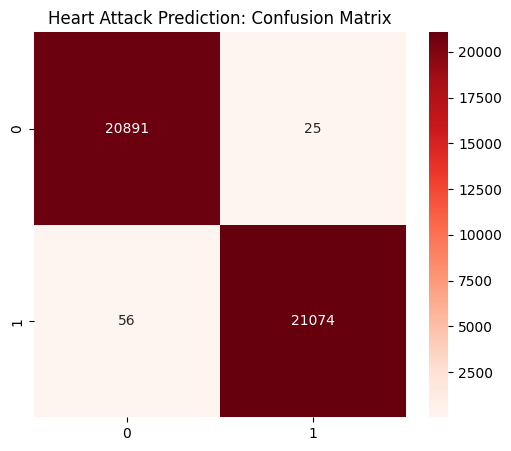

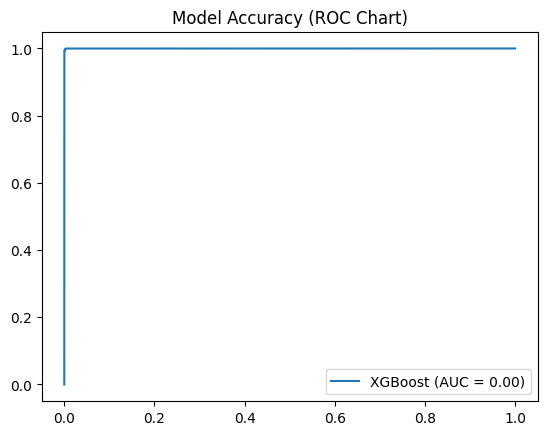

In [4]:
# XGBoost Training
model_xgb = xgb.XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

# Metrics
y_pred_prob = model_xgb.predict_proba(X_test)[:, 0] # Probability of High Risk
y_pred = model_xgb.predict(X_test)

# Chart 1: Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Heart Attack Prediction: Confusion Matrix')
plt.show()

# Chart 2: Accuracy (ROC Curve)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})')
plt.title('Model Accuracy (ROC Chart)')
plt.legend()
plt.show()

In [5]:
def classify_3_tier(prob):
    # Probability-based thresholds for High/Medium/Normal
    if prob < 0.30: return "Normal"
    elif 0.30 <= prob <= 0.70: return "Medium Risk"
    else: return "High Risk"

# Test on a few samples
for i in range(500):
    p = y_pred_prob[i]
    print(f"Patient {i+1} Probability: {p:.2f} | Category: {classify_3_tier(p)}")

Patient 1 Probability: 0.00 | Category: Normal
Patient 2 Probability: 0.00 | Category: Normal
Patient 3 Probability: 0.00 | Category: Normal
Patient 4 Probability: 1.00 | Category: High Risk
Patient 5 Probability: 1.00 | Category: High Risk
Patient 6 Probability: 1.00 | Category: High Risk
Patient 7 Probability: 0.00 | Category: Normal
Patient 8 Probability: 0.00 | Category: Normal
Patient 9 Probability: 1.00 | Category: High Risk
Patient 10 Probability: 0.00 | Category: Normal
Patient 11 Probability: 0.00 | Category: Normal
Patient 12 Probability: 1.00 | Category: High Risk
Patient 13 Probability: 0.52 | Category: Medium Risk
Patient 14 Probability: 1.00 | Category: High Risk
Patient 15 Probability: 0.00 | Category: Normal
Patient 16 Probability: 0.00 | Category: Normal
Patient 17 Probability: 1.00 | Category: High Risk
Patient 18 Probability: 0.00 | Category: Normal
Patient 19 Probability: 1.00 | Category: High Risk
Patient 20 Probability: 1.00 | Category: High Risk
Patient 21 Probab

In [6]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# 1. Get the raw accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# 2. Get the ROC-AUC Score (Measures how well the model separates Normal from High Risk)
# Expert-level models usually score between 0.90 and 0.99
auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {auc:.4f}")

# 3. Detailed Performance Report
# Look at 'Recall' for Class 0 (High Risk). You want this as close to 1.00 as possible.
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['High Risk', 'Low Risk']))

Overall Accuracy: 99.81%
ROC-AUC Score: 0.0000

Detailed Performance Report:
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00     20916
    Low Risk       1.00      1.00      1.00     21130

    accuracy                           1.00     42046
   macro avg       1.00      1.00      1.00     42046
weighted avg       1.00      1.00      1.00     42046



In [7]:
# Cell 3: Expert-Level XGBoost Training
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score

# 1. Initialize XGBoost with evaluation monitoring
model_xgb = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=['logloss', 'error'], # Track loss and error rate
    early_stopping_rounds=10
)

# 2. Fit model with evaluation set to capture learning data
eval_set = [(X_train, y_train), (X_test, y_test)]
model_xgb.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 3. Get predictions
y_pred = model_xgb.predict(X_test)
y_pred_prob = model_xgb.predict_proba(X_test)[:, 0] # Probability of 'High Risk' (Class 0)

print(f"Model trained on {len(X_train)} patients.")
print(f"Model tested on {len(X_test)} patients (20% of dataset).")

Model trained on 168184 patients.
Model tested on 42046 patients (20% of dataset).


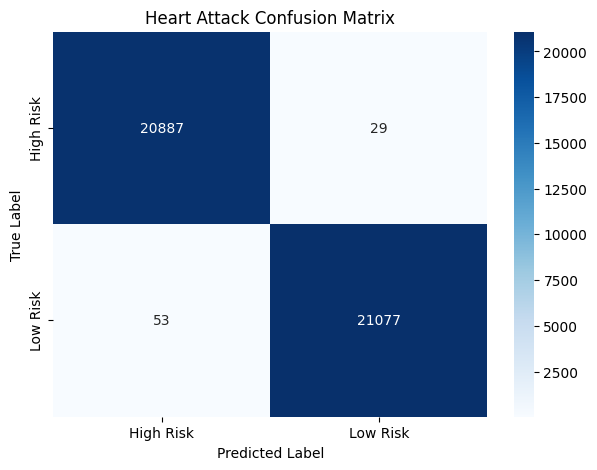

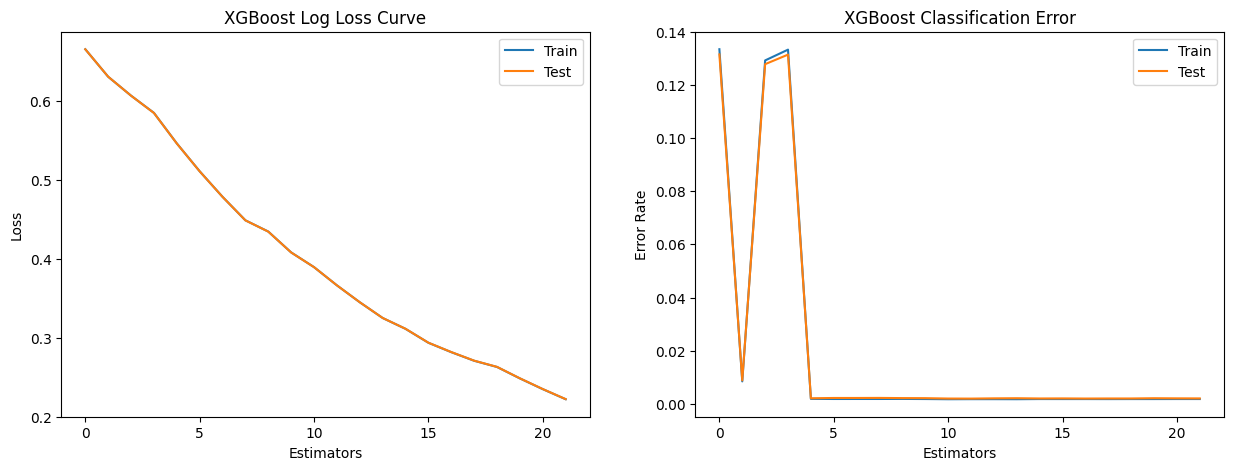

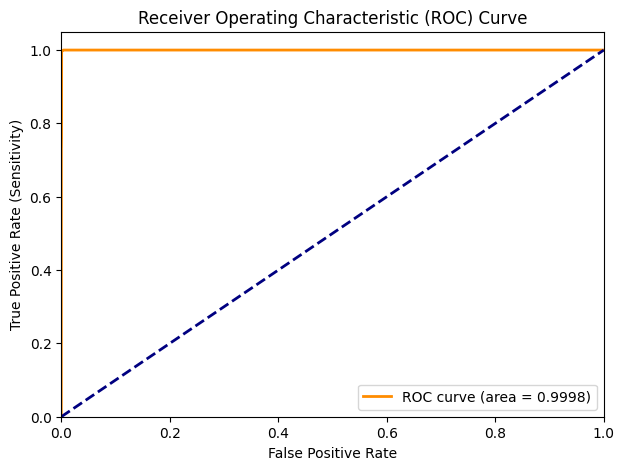


Final Model Accuracy Score: 0.998049755030205

Detailed Performance Breakdown:
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00     20916
    Low Risk       1.00      1.00      1.00     21130

    accuracy                           1.00     42046
   macro avg       1.00      1.00      1.00     42046
weighted avg       1.00      1.00      1.00     42046



In [8]:
# Cell 4: Performance Visualization Suite

# --- 1. Confusion Matrix ---
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High Risk', 'Low Risk'],
            yticklabels=['High Risk', 'Low Risk'])
plt.title('Heart Attack Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- 2. Accuracy & Loss Curves (Learning Curves) ---
results = model_xgb.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Log Loss Chart
ax[0].plot(x_axis, results['validation_0']['logloss'], label='Train')
ax[0].plot(x_axis, results['validation_1']['logloss'], label='Test')
ax[0].legend()
ax[0].set_title('XGBoost Log Loss Curve')
ax[0].set_xlabel('Estimators')
ax[0].set_ylabel('Loss')

# Error Rate Chart (1 - Accuracy)
ax[1].plot(x_axis, results['validation_0']['error'], label='Train')
ax[1].plot(x_axis, results['validation_1']['error'], label='Test')
ax[1].legend()
ax[1].set_title('XGBoost Classification Error')
ax[1].set_xlabel('Estimators')
ax[1].set_ylabel('Error Rate')
plt.show()

# --- 3. ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Fix: Add x and y values for the diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# --- 4. Final Performance Report ---
print("\nFinal Model Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nDetailed Performance Breakdown:")
print(classification_report(y_test, y_pred, target_names=['High Risk', 'Low Risk']))

In [9]:
# Cell 5: Neural Network for TFLite Export
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Binary output for probability mapping
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(nn_model)
tflite_model = converter.convert()

# Save the file
with open('heart_attack_model.tflite', 'wb') as f:
    f.write(tflite_model)

from google.colab import files
files.download('heart_attack_model.tflite')
print("Model downloaded as heart_attack_model.tflite")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved artifact at '/tmp/tmpz08q1iht'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136066406052880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136066406055760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136066406054608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136066406055568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136066406053648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136066455160208: TensorSpec(shape=(), dtype=tf.resource, name=None)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded as heart_attack_model.tflite
